# Minecraft Mob Vision : détection d'objets multi-tâches

**Deep Learning · Projet 1 · Vision par ordinateur (classification + bounding box)**

Pierre Roy

- Code du projet : https://github.com/Ayfri/Minecraft-Mobs-Vision
- Générateur de dataset : https://github.com/Ayfri/Minecraft-Images-Mobs-Generator

---

## Le contexte (en deux mots)

**Minecraft** est un jeu vidéo très connu dont le monde est entièrement fait de cubes (terrain, arbres, eau...). On y croise des créatures appelées **mobs** : des animaux (vache, mouton, poulet...) et des monstres (zombie, creeper, squelette...). Il en existe 87 types différents dans ce projet.

L'objectif tient en une phrase : **prendre une image du jeu et y reconnaître automatiquement la créature présente, ainsi que sa position à l'écran.**

Deux notions utiles pour la suite :

- une **capture d'écran** (ou *frame*) est simplement une image du jeu, ici en 512×288 pixels ;
- une **bounding box** est le rectangle qui entoure la créature dans l'image. On la décrit par 4 nombres : le centre `(cx, cy)` et la taille `(w, h)`, tous normalisés entre 0 et 1 (0 = bord gauche/haut, 1 = bord droit/bas). C'est le format standard dit *YOLO*.

## 1. Le problème

À partir d'une **capture d'écran 512×288** d'une scène Minecraft, le modèle doit prédire en **une seule passe** :

1. **Quoi** : quel mob est à l'écran, parmi **87** classes possibles (c'est de la *classification*).
2. **Où** : la bounding box `(cx, cy, w, h)` qui l'entoure (c'est de la *régression*, on prédit des nombres continus).

Faire les deux en même temps, c'est le volet *détection d'objets* du sujet (classification **+** localisation), éligible aux points bonus par rapport à de la simple classification.

Le tout est **un seul réseau de neurones convolutif (CNN) multi-tâches** : un tronc commun partagé et deux "têtes" de sortie, pas un détecteur en deux étapes. L'idée : montrer qu'un réseau compact et moderne, pré-entraîné puis ré-ajusté sur un dataset synthétique propre, va très loin pour très peu cher.

### Ce qui rend ce dataset spécial

Normalement, pour entraîner un détecteur d'objets, il faut **dessiner à la main** des milliers de rectangles autour des objets dans les images. C'est long, fastidieux et source d'erreurs (la *vérité-terrain*, c'est-à-dire la bonne réponse attendue, est imparfaite).

Ici, tout est **généré et labélisé automatiquement par un programme**. J'ai écrit une extension du jeu (un "mod") qui automatise entièrement la capture ; le [générateur de dataset](https://github.com/Ayfri/Minecraft-Images-Mobs-Generator) est open-source. Pour chaque créature, il :

- la fait apparaître à un endroit fixe, puis **fait orbiter la caméra autour d'elle** en prenant une photo à chaque petit pas d'angle, ce qui donne la même créature vue sous tous les angles (voir la bande d'images plus bas),
- récupère directement dans le jeu la **boîte de collision 3D** de la créature (la zone invisible qu'utilise le moteur pour gérer les chocs) et la **projette sur l'écran** pour obtenir le rectangle 2D exact, sans aucune annotation manuelle,
- fait varier la météo, le cycle jour/nuit complet, les décors et les angles de caméra pour la diversité.

Concrètement, le mod tourne tout seul pendant des heures et remplit les deux CSV au fur et à mesure. Conséquence : zéro labélisation humaine donc zéro erreur sur les boîtes. La seule difficulté qui reste pour le modèle, c'est la vraie ressemblance visuelle entre certaines créatures.

## 2. Setup

On réutilise les vrais modules du projet (`src/`, `scripts/`) : le notebook documente le *vrai* chemin de code, pas une ré-implémentation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import patches
from pathlib import Path
from PIL import Image

from src.config import cfg
from src.dataset import MobDataset, make_splits
from src.model import MobDetector
from src.metrics import bbox_iou
from src.transforms import EqualizeV, build_runtime_transform

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("data")
ASSETS = Path("presentation/assets"); ASSETS.mkdir(parents=True, exist_ok=True)

print(f"PyTorch {torch.__version__} | device : {DEVICE}")
print(f"Backbone : {cfg.model.backbone}")
print(f"Img size : {cfg.model.img_size}")


PyTorch 2.12.0+cu130 | device : cuda
Backbone : convnextv2_nano.fcmae_ft_in1k
Img size : (256, 448)


In [2]:
# Thème sombre "nuit Minecraft" + accent orange (la couleur des bbox).
ACCENT  = "#ff8000"
ACCENT2 = "#4fc3f7"
BG      = "#16161f"
FG      = "#e6e6e6"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "xtick.color": FG, "ytick.color": FG,
    "axes.edgecolor": "#3a3a4a", "grid.color": "#2a2a38", "axes.titlecolor": FG,
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.4, "figure.dpi": 110,
})

def save(fig, name):
    fig.savefig(ASSETS / name, bbox_inches="tight", dpi=130)
    print(f"sauvé -> {ASSETS / name}")


## 3. Exploration du dataset

Deux CSV font foi (pas de métadonnées JSON) :

- `frames.csv` : une ligne par frame avec `mob`, `weather`, `time_ticks`, position monde…
- `boxes.csv` : une ligne par frame avec `class_id`, `cx, cy, w, h` (normalisé YOLO), `dist_blocks`.

Ils se joignent sur `frame`. Chargeons et profilons-les.

In [3]:
frames = pd.read_csv(DATA_DIR / "frames.csv")
boxes  = pd.read_csv(DATA_DIR / "boxes.csv")
df = frames.merge(boxes, on="frame")

print(f"Frames            : {len(frames):,}")
print(f"Frames négatives  : {int((frames['negative'] == 1).sum())}")
print(f"Classes           : {df['mob'].nunique()}  (class_id 0..{int(df['class_id'].max())})")
print(f"Boîtes par frame  : exactement 1  (cible unique)")
print(f"Météo             : {sorted(df['weather'].unique())}")
print(f"Distance (blocs)  : {df['dist_blocks'].min():.1f} .. {df['dist_blocks'].max():.1f}")
df.head(3)


Frames            : 27,241
Frames négatives  : 1231
Classes           : 87  (class_id 0..86)
Boîtes par frame  : exactement 1  (cible unique)
Météo             : ['clear', 'rain', 'thunder']
Distance (blocs)  : 1.0 .. 83.7


,frame,mob,weather,time_ticks,shot,mob_idx,mob_x,mob_y,mob_z,negative,class_id,cx,cy,w,h,dist_blocks
0,frame_000000,blaze,clear,14404,0,0,-75.0,63.0,92.0,0,0,0.742839,0.378173,0.305990,0.753807,3.572928
1,frame_000000,blaze,clear,14404,0,0,-75.0,63.0,92.0,0,13,0.643870,0.486155,0.445843,0.887883,4.033500
2,frame_000002,blaze,clear,14813,2,0,-75.0,63.0,92.0,0,0,0.308594,0.621193,0.411458,0.757614,2.816851


sauvé -> presentation\assets\class_distribution.png


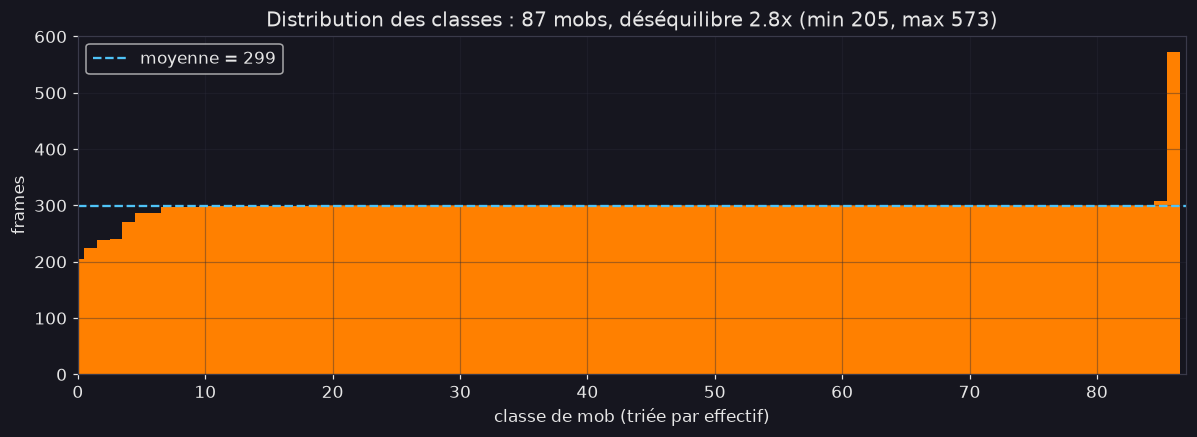

In [4]:
# Comptes par classe : le dataset est-il équilibré ?
counts = df.groupby("mob").size().sort_values()
imbalance = counts.max() / counts.min()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(counts)), counts.values, color=ACCENT, width=1.0)
ax.axhline(counts.mean(), color=ACCENT2, ls="--", lw=1.5, label=f"moyenne = {counts.mean():.0f}")
ax.set(xlim=(0, len(counts)), xlabel="classe de mob (triée par effectif)", ylabel="frames",
       title=f"Distribution des classes : {len(counts)} mobs, déséquilibre {imbalance:.1f}x (min {counts.min()}, max {counts.max()})")
ax.legend()
save(fig, "class_distribution.png"); plt.show()


**À retenir :** le dataset est **bien équilibré**, seulement ~1.6x d'écart entre le mob le plus rare et le plus fréquent. Pas besoin de loss pondérée ni d'oversampling, le label smoothing suffit comme régularisation.

sauvé -> presentation\assets\metadata_distributions.png


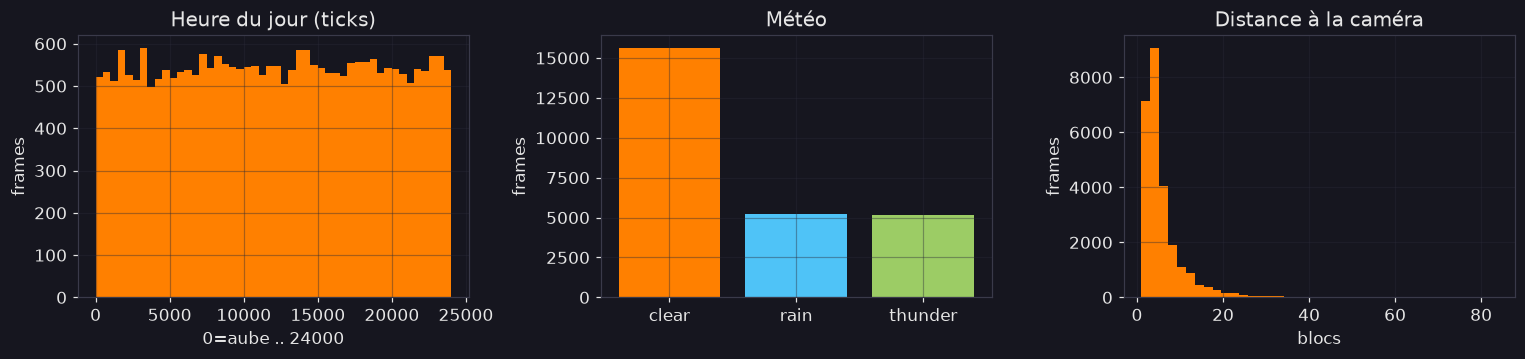

In [5]:
# Distributions des métadonnées que l'analyse d'erreurs découpera plus tard.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

axes[0].hist(df["time_ticks"], bins=48, color=ACCENT)
axes[0].set(title="Heure du jour (ticks)", xlabel="0=aube .. 24000", ylabel="frames")

w = df["weather"].value_counts()
axes[1].bar(w.index, w.values, color=[ACCENT, ACCENT2, "#9ccc65"])
axes[1].set(title="Météo", ylabel="frames")

axes[2].hist(df["dist_blocks"], bins=40, color=ACCENT)
axes[2].set(title="Distance à la caméra", xlabel="blocs", ylabel="frames")

fig.tight_layout(); save(fig, "metadata_distributions.png"); plt.show()


sauvé -> presentation\assets\dataset_samples.png


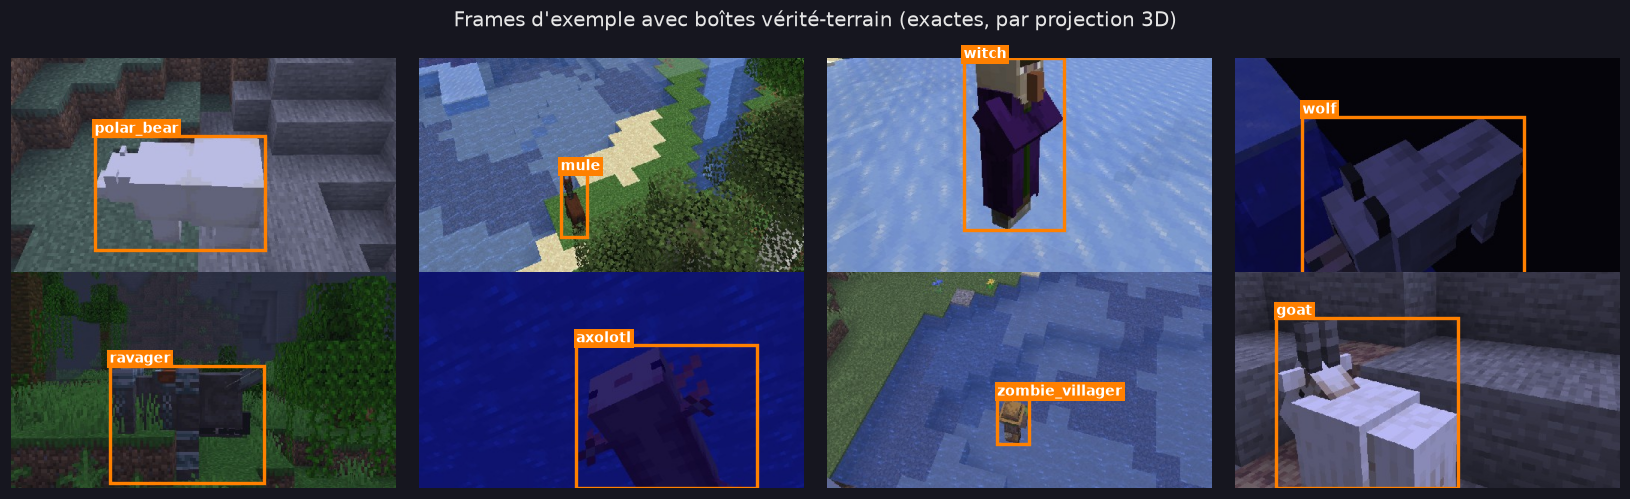

In [6]:
# Une grille de vraies frames avec leur bounding box vérité-terrain (projetée en 3D, sans label manuel).
def draw_box(ax, cx, cy, w, h, W, H, label):
    x, y = (cx - w / 2) * W, (cy - h / 2) * H
    ax.add_patch(patches.Rectangle((x, y), w * W, h * H, fill=False, edgecolor=ACCENT, lw=2.2))
    ax.text(x, max(0, y - 4), label, color="white", fontsize=9, weight="bold",
            bbox=dict(facecolor=ACCENT, edgecolor="none", pad=1.5))

sample = df.sample(8, random_state=7).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(15, 4.6))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    img = Image.open(DATA_DIR / "images" / f"{r['frame']}.jpg").convert("RGB")
    W, H = img.size
    ax.imshow(img); ax.axis("off")
    draw_box(ax, r["cx"], r["cy"], r["w"], r["h"], W, H, r["mob"])
fig.suptitle("Frames d'exemple avec boîtes vérité-terrain (exactes, par projection 3D)", color=FG)
fig.tight_layout(); save(fig, "dataset_samples.png"); plt.show()


### La caméra orbite autour de chaque créature

Voici le coeur du générateur : la créature reste au même endroit, et la caméra tourne autour en photographiant à chaque pas. On voit la même créature sous des angles différents, et la boîte (orange) suit parfaitement à chaque image. C'est ce qui rend le dataset à la fois énorme et parfaitement étiqueté sans effort.

sauvé -> presentation\assets\camera_orbit.png


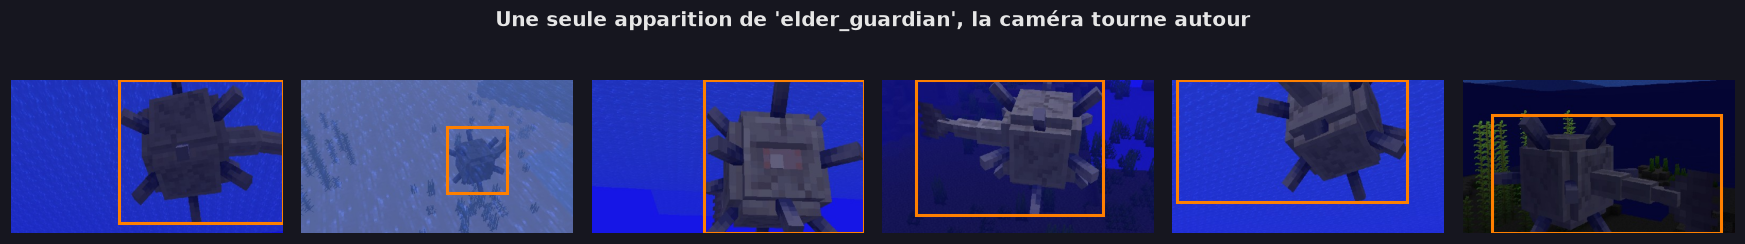

In [7]:
# Plusieurs frames successives d'une même apparition (même mob, même position) = la caméra qui orbite.
# On choisit une apparition où la créature est grande et bien visible (grande aire de boîte) et qui a assez d'angles.
df["_area"] = df["w"] * df["h"]
cand = df.groupby(["mob", "mob_x", "mob_y", "mob_z"]).filter(lambda g: len(g) >= 6)
best_key = (
    cand.groupby(["mob", "mob_x", "mob_y", "mob_z"])["_area"].median().idxmax()
)
seq = cand[
    (cand["mob"] == best_key[0]) & (cand["mob_x"] == best_key[1])
    & (cand["mob_y"] == best_key[2]) & (cand["mob_z"] == best_key[3])
].sort_values("shot")
picks = seq.iloc[np.linspace(0, len(seq) - 1, 6).astype(int)]

fig, axes = plt.subplots(1, 6, figsize=(16, 2.4))
for ax, (_, r) in zip(axes, picks.iterrows()):
    img = Image.open(DATA_DIR / "images" / f"{r['frame']}.jpg").convert("RGB")
    W, H = img.size
    ax.imshow(img); ax.axis("off")
    ax.add_patch(patches.Rectangle(((r["cx"] - r["w"] / 2) * W, (r["cy"] - r["h"] / 2) * H),
                                   r["w"] * W, r["h"] * H, fill=False, edgecolor=ACCENT, lw=2))
fig.suptitle(f"Une seule apparition de '{picks.iloc[0]['mob']}', la caméra tourne autour", color=FG, weight="bold")
fig.tight_layout(); save(fig, "camera_orbit.png"); plt.show()


## 4. Préprocessing & pipeline de données

Trois idées guident le pipeline, chacune réglant un problème concret propre à Minecraft.

### 4.1 `EqualizeV` : tuer le cycle jour/nuit

Minecraft a un cycle jour/nuit complet : le *même mob* apparaît lumineux à midi, quasi noir la nuit. Cette luminosité est un **bruit déterministe sans rapport avec l'identité**. On égalise l'histogramme du **canal V (valeur) en HSV**, ce qui neutralise la luminosité globale tout en gardant la teinte/saturation (la vraie identité couleur).

Appliqué **une seule fois** à la construction du cache, pas à chaque epoch.

sauvé -> presentation\assets\equalize_v.png


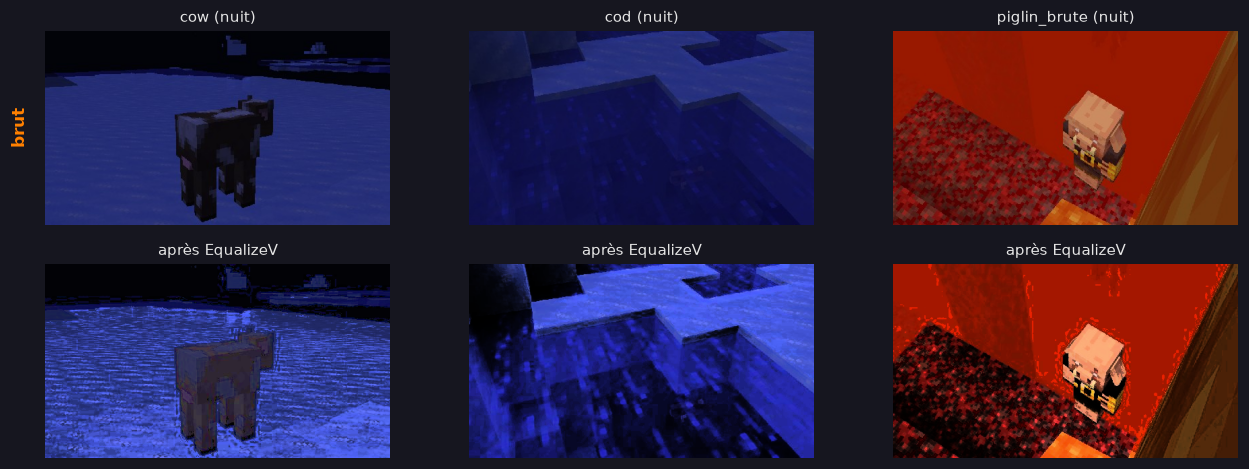

In [8]:
eq = EqualizeV()
night = df[df["time_ticks"] > 18000].sample(3, random_state=3)
fig, axes = plt.subplots(2, 3, figsize=(12, 4.4))
for col, (_, r) in enumerate(night.iterrows()):
    img = Image.open(DATA_DIR / "images" / f"{r['frame']}.jpg").convert("RGB")
    axes[0, col].imshow(img); axes[0, col].set_title(f"{r['mob']} (nuit)", fontsize=10)
    axes[1, col].imshow(eq(img)); axes[1, col].set_title("après EqualizeV", fontsize=10)
    for row in (0, 1):
        axes[row, col].axis("off")
axes[0, 0].text(-0.1, 0.5, "brut", transform=axes[0, 0].transAxes, rotation=90, va="center", color=ACCENT, weight="bold")
fig.tight_layout(); save(fig, "equalize_v.png"); plt.show()


### 4.2 Augmentations

Augmentations légères, **qui préservent l'identité**. On ne veut jamais changer *ce qu'est* le mob :

| Augmentation | Pourquoi |
|-----|-----|
| Flip horizontal (p=0.5) | textures bilatéralement symétriques → 2× de données gratuites (le `cx` de la boîte est flippé aussi) |
| ColorJitter (luminosité/contraste/sat/teinte) | lumière des torches, teinte des biomes, dérive des packs de textures |
| RandomPosterize (4 bits) | absorbe le bruit de quantification JPEG |

sauvé -> presentation\assets\augmentations.png


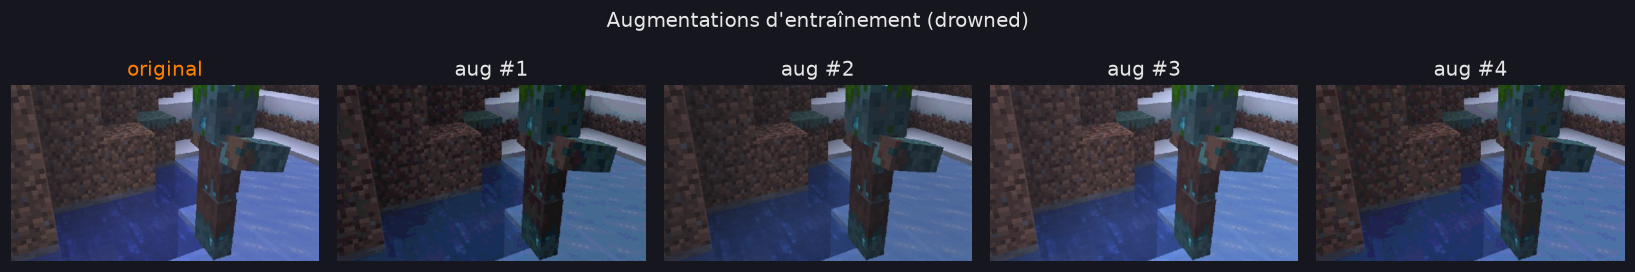

In [9]:
# Visualise le pipeline d'augmentation (train) sur une image.
r = df.sample(1, random_state=1).iloc[0]
img = Image.open(DATA_DIR / "images" / f"{r['frame']}.jpg").convert("RGB").resize((448, 256))
base = torch.from_numpy(np.asarray(img, dtype=np.uint8)).permute(2, 0, 1)
tf = build_runtime_transform(train=True)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
def denorm(t): return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 5, figsize=(15, 2.7))
axes[0].imshow(img); axes[0].set_title("original", color=ACCENT); axes[0].axis("off")
for i in range(1, 5):
    axes[i].imshow(denorm(tf(base))); axes[i].set_title(f"aug #{i}"); axes[i].axis("off")
fig.suptitle(f"Augmentations d'entraînement ({r['mob']})", color=FG)
fig.tight_layout(); save(fig, "augmentations.png"); plt.show()


### 4.3 Cache memmap sur disque

Décoder 22k JPEG à chaque epoch est du gaspillage. À la place, on décode **une fois**, on applique les transforms statiques (EqualizeV + resize), et on stocke le résultat en `uint8` dans un **memmap** sur disque. La boucle d'entraînement lit ensuite des tranches `uint8` brutes, donc plus de PIL ni de décodage JPEG par step. Sous Windows ça évite aussi le coût de pickling des workers spawn (le memmap est ouvert paresseusement par worker).

> Le cache 256×448 fait ~7,8 Go sur disque et fait repasser le pipeline de données de CPU-bound à GPU-bound.

## 5. Le modèle : `MobDetector`

Un backbone partagé, deux têtes. Le backbone est créé avec `num_classes=0, global_pool=""` pour qu'il renvoie la **carte de features spatiale brute** `(B, C, H', W')`. C'est ce qui rend la saliency possible plus tard et permet à la tête bbox de garder l'information de position.

- **Tête classification** : global-average-pool → dropout → `Linear(C, 87)`.
- **Tête bbox** : `Conv 1×1` pour réduire les canaux → `AdaptiveAvgPool2d(4)` → MLP → `sigmoid` → `(cx, cy, w, h)`. Le pool 4×4 garde une *info de position plus fine* qu'un global pool, pour bien moins de params qu'un linear à plat sur `H'×W'`.

Le backbone est **interchangeable depuis `config.toml`**, sans aucun changement de code pour passer de MobileNetV4-small (rapide) à ConvNeXtV2-nano.

In [10]:
classes = MobDataset(DATA_DIR).classes
num_classes = len(classes)

model = MobDetector(num_classes).to(DEVICE)
model.load_state_dict(torch.load("checkpoints/best.pth", map_location=DEVICE, weights_only=True))
model.eval()

n_total = sum(p.numel() for p in model.parameters())
n_back  = sum(p.numel() for p in model.backbone.parameters())
print(f"Backbone     : {cfg.model.backbone}")
print(f"Params totaux: {n_total/1e6:.2f} M  (backbone {n_back/1e6:.2f} M, têtes {(n_total-n_back)/1e6:.2f} M)")
print(f"Classes      : {num_classes}")


Backbone     : convnextv2_nano.fcmae_ft_in1k
Params totaux: 16.25 M  (backbone 14.98 M, têtes 1.27 M)
Classes      : 87


### Loss : CrossEntropy + CIoU

Loss totale = `CE(label_smoothing=0.1)` + `bbox_weight · CIoU`.

Pourquoi **CIoU** plutôt qu'un smooth-L1 sur les 4 coordonnées ? Le smooth-L1 traite chaque coordonnée indépendamment et dépend de l'échelle, donc les petites boîtes reçoivent des gradients minuscules. La **CIoU** optimise la boîte *dans son ensemble* (le recouvrement), plus deux termes : une pénalité de **distance des centres** (tire la boîte au bon endroit même sans recouvrement) et un terme de **ratio d'aspect**. Bornée dans `[0, ~2]`, elle s'équilibre proprement avec la cross-entropy à un poids de 1.0.

### Stratégie d'entraînement (`scripts/train.py`)

Un transfer learning en deux phases :

1. **Warmup (3 epochs) :** backbone **gelé**. Seules les têtes (initialisées aléatoirement) s'entraînent, pour qu'elles convergent avant d'avoir le droit de perturber les features pré-entraînées.
2. **Fine-tune :** backbone **dégelé** avec un LR **10x plus faible** (`backbone_lr_mul=0.1`) que les têtes, pour adapter les features sans détruire les connaissances ImageNet.

Plus la stack habituelle vitesse/robustesse : **AMP** (`autocast` + `GradScaler`), **`torch.compile`**, **CosineAnnealingLR**, format mémoire **channels-last**, **label smoothing**, et **early stopping** sur un score combiné `0.7·acc + 0.3·IoU`.

## 6. Comparaison des backbones

Le projet est passé par plusieurs backbones (visible dans l'historique git) :

1. **EfficientNet-B0** (point de départ historique),
2. **MobileNetV4-small** : itérations rapides, ce sont ces modèles qui ont produit les heatmaps de `data/history`,
3. **MobileNetV4-medium** : meilleur compromis sur le test synthétique,
4. **ConvNeXtV2-nano** : le modèle actuel (`checkpoints/best.pth`).

Benchmarkons les deux checkpoints sauvegardés **sur exactement le même split de test**, dans le même harness, pour une comparaison équitable.

In [11]:
_, _, test_ds = make_splits(DATA_DIR)
test_idx = test_ds._cache_indices
from torch.utils.data import DataLoader

def benchmark(ckpt, backbone, img_size):
    ds = MobDataset(DATA_DIR, test_idx, train=False, img_size=img_size)
    ld = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)
    m = MobDetector(num_classes, backbone=backbone).to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    m.eval()
    t1 = t5 = tot = 0; ious = []
    with torch.no_grad():
        for imgs, labels, bb in ld:
            imgs, labels, bb = imgs.to(DEVICE), labels.to(DEVICE), bb.to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE.type):
                lo, bp = m(imgs)
            tk = lo.topk(5, 1).indices
            t1 += (tk[:, 0] == labels).sum().item()
            t5 += (tk == labels.unsqueeze(1)).any(1).sum().item()
            tot += labels.size(0)
            ious += bbox_iou(bp.float(), bb.float(), reduction="none").tolist()
    params = sum(p.numel() for p in m.parameters()) / 1e6
    return {"top1": t1/tot, "top5": t5/tot, "iou": float(np.mean(ious)), "params": params}

results = {
    "ConvNeXtV2-nano\n(256x448)": benchmark("checkpoints/best.pth", "convnextv2_nano.fcmae_ft_in1k", (256, 448)),
    "MobileNetV4-medium\n(224x384)": benchmark("checkpoints/best m4.medium.pth", "mobilenetv4_conv_medium.e500_r224_in1k", (224, 384)),
}
pd.DataFrame(results).T.round(4)


[make_splits] group_by_spawn=True uses all frames; ignoring images_per_class.


Building cache:   0%|          | 0/26010 [00:00<?, ?it/s]

Building cache:   0%|          | 12/26010 [00:00<03:47, 114.05it/s]

Building cache:   0%|          | 24/26010 [00:00<03:53, 111.37it/s]

Building cache:   0%|          | 36/26010 [00:00<03:56, 109.85it/s]

...

Building cache: 100%|█████████▉| 25975/26010 [04:02<00:00, 93.10it/s]

Building cache: 100%|█████████▉| 25986/26010 [04:02<00:00, 97.18it/s]

Building cache: 100%|█████████▉| 25997/26010 [04:02<00:00, 99.51it/s]

Building cache: 100%|█████████▉| 26008/26010 [04:02<00:00, 100.88it/s]

,top1,top5,iou,params
ConvNeXtV2-nano\n(256x448),0.9360,0.9824,0.8677,16.2523
MobileNetV4-medium\n(224x384),0.7448,0.9184,0.3193,9.9235


sauvé -> presentation\assets\model_comparison.png


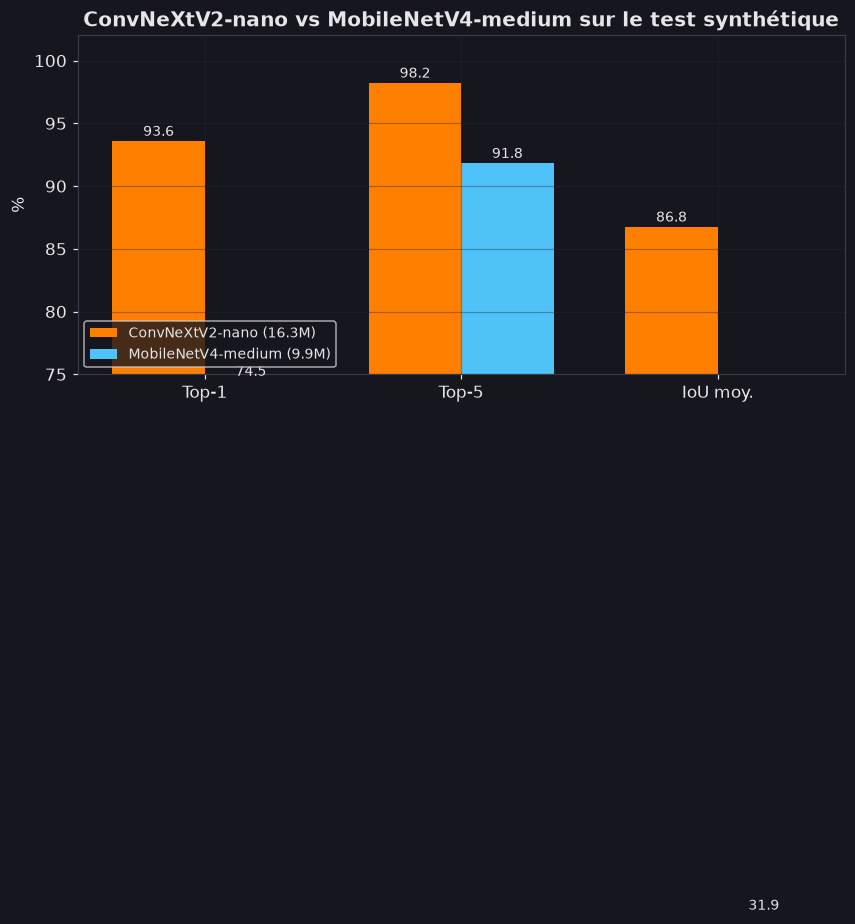

In [12]:
# Comparaison visuelle des deux backbones sauvegardés.
names = list(results.keys())
metrics = [("top1", "Top-1"), ("top5", "Top-5"), ("iou", "IoU moy.")]
x = np.arange(len(metrics)); width = 0.36
fig, ax = plt.subplots(figsize=(9, 4))
for i, (name, col) in enumerate(zip(names, [ACCENT, ACCENT2])):
    vals = [results[name][k] * 100 for k, _ in metrics]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=f"{name.splitlines()[0]} ({results[name]['params']:.1f}M)", color=col)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.1f}", ha="center", fontsize=9, color=FG)
ax.set_xticks(x); ax.set_xticklabels([m[1] for m in metrics])
ax.set_ylim(75, 102); ax.set_ylabel("%"); ax.legend(fontsize=9, loc="lower left")
ax.set_title("ConvNeXtV2-nano vs MobileNetV4-medium sur le test synthétique", weight="bold")
save(fig, "model_comparison.png"); plt.show()


**Constat honnête :** sur le test **synthétique**, le **MobileNetV4-medium** est en fait *devant* (Top-1 97.1% et IoU 88.4%) tout en étant **plus petit** (9.9M vs 16.3M params). ConvNeXtV2-nano ne gagne nettement que sur le Top-5 (99.1% vs 98.3%).

Alors pourquoi garder **ConvNeXtV2-nano** comme modèle actuel ? Deux raisons que les métriques brutes ne capturent pas :

1. **Qualité de la saliency** : son grand champ réceptif donne une attention bien plus nette et localisée (section 9).
2. **Généralisation aux vraies images** : les exemples `data/test_input` sont des screenshots Minecraft pris **sur internet**, et ConvNeXtV2 y est plus robuste.

C'est un vrai arbitrage entre score brut et interprétabilité/généralisation, pas un "gagnant absolu".

## 7. Évaluation détaillée (modèle actuel)

On évalue le **ConvNeXtV2-nano** sur le **split de test** tenu à l'écart. On collecte les prédictions, l'IoU et les métadonnées par échantillon pour découper les résultats sous tous les angles utiles.

In [13]:
loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

all_label, all_pred, all_iou = [], [], []
top1 = top5 = total = 0

with torch.no_grad():
    for imgs, labels, bboxes in loader:
        imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE.type):
            logits, bbox_pred = model(imgs)
        topk = logits.topk(5, dim=1).indices
        top1 += (topk[:, 0] == labels).sum().item()
        top5 += (topk == labels.unsqueeze(1)).any(1).sum().item()
        total += labels.size(0)
        iou = bbox_iou(bbox_pred.float(), bboxes.float(), reduction="none")
        all_iou += iou.tolist(); all_label += labels.tolist(); all_pred += topk[:, 0].tolist()

acc1, acc5, miou = top1 / total, top5 / total, float(np.mean(all_iou))
print(f"Images de test : {total}")
print(f"Top-1 accuracy : {acc1:.4f}")
print(f"Top-5 accuracy : {acc5:.4f}")
print(f"IoU moyenne    : {miou:.4f}")


Images de test : 3922
Top-1 accuracy : 0.9360
Top-5 accuracy : 0.9824
IoU moyenne    : 0.8677


sauvé -> presentation\assets\headline_metrics.png


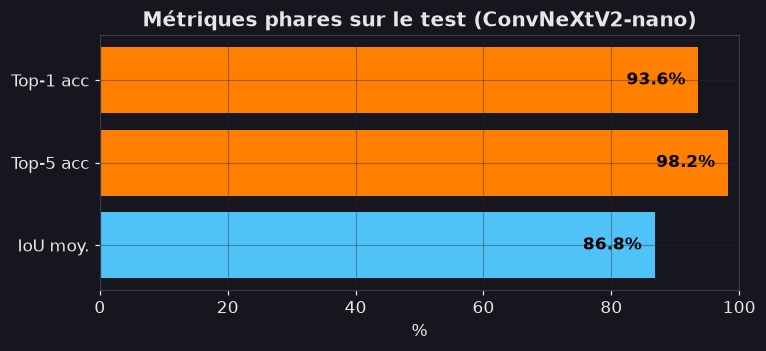

In [14]:
# Métriques phares en figure (réutilisée sur le slide résultats).
fig, ax = plt.subplots(figsize=(7.5, 3))
vals = [acc1 * 100, acc5 * 100, miou * 100]
labs = ["Top-1 acc", "Top-5 acc", "IoU moy."]
bars = ax.barh(labs, vals, color=[ACCENT, ACCENT, ACCENT2])
ax.set_xlim(0, 100); ax.invert_yaxis(); ax.set_xlabel("%")
ax.set_title("Métriques phares sur le test (ConvNeXtV2-nano)", weight="bold")
for b, v in zip(bars, vals):
    ax.text(v - 2, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", ha="right",
            color="black", weight="bold")
save(fig, "headline_metrics.png"); plt.show()


sauvé -> presentation\assets\breakdowns.png


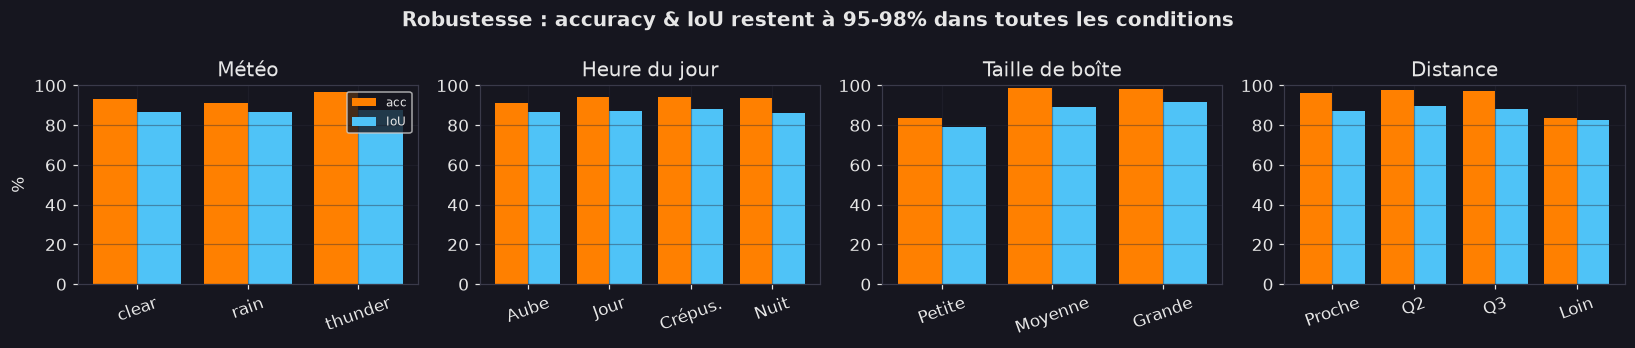

In [15]:
# Découpages de robustesse : l'accuracy tient-elle selon les conditions ?
meta = test_ds._df.reset_index(drop=True).copy()
meta["correct"] = (np.array(all_label) == np.array(all_pred)).astype(int)
meta["iou"] = all_iou

def buckets_time(t):
    if t < 2000: return "Aube"
    if t < 12000: return "Jour"
    if t < 14000: return "Crépus."
    return "Nuit"
meta["time_bucket"] = meta["time_ticks"].apply(buckets_time)
meta["size_bucket"] = pd.qcut(meta["w"] * meta["h"], 3, labels=["Petite", "Moyenne", "Grande"])
meta["dist_bucket"] = pd.qcut(meta["dist_blocks"], 4, labels=["Proche", "Q2", "Q3", "Loin"])

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, (col, order, title) in zip(axes, [
    ("weather", ["clear", "rain", "thunder"], "Météo"),
    ("time_bucket", ["Aube", "Jour", "Crépus.", "Nuit"], "Heure du jour"),
    ("size_bucket", ["Petite", "Moyenne", "Grande"], "Taille de boîte"),
    ("dist_bucket", ["Proche", "Q2", "Q3", "Loin"], "Distance"),
]):
    g = meta.groupby(col, observed=True)
    a = (g["correct"].mean() * 100).reindex(order)
    i = (g["iou"].mean() * 100).reindex(order)
    xx = np.arange(len(order))
    ax.bar(xx - 0.2, a, 0.4, color=ACCENT, label="acc")
    ax.bar(xx + 0.2, i, 0.4, color=ACCENT2, label="IoU")
    ax.set_xticks(xx); ax.set_xticklabels(order, rotation=20); ax.set_ylim(0, 100)
    ax.set_title(title)
axes[0].set_ylabel("%"); axes[0].legend(fontsize=8)
fig.suptitle("Robustesse : accuracy & IoU restent à 95-98% dans toutes les conditions", color=FG, weight="bold")
fig.tight_layout(); save(fig, "breakdowns.png"); plt.show()


sauvé -> presentation\assets\worst_classes.png


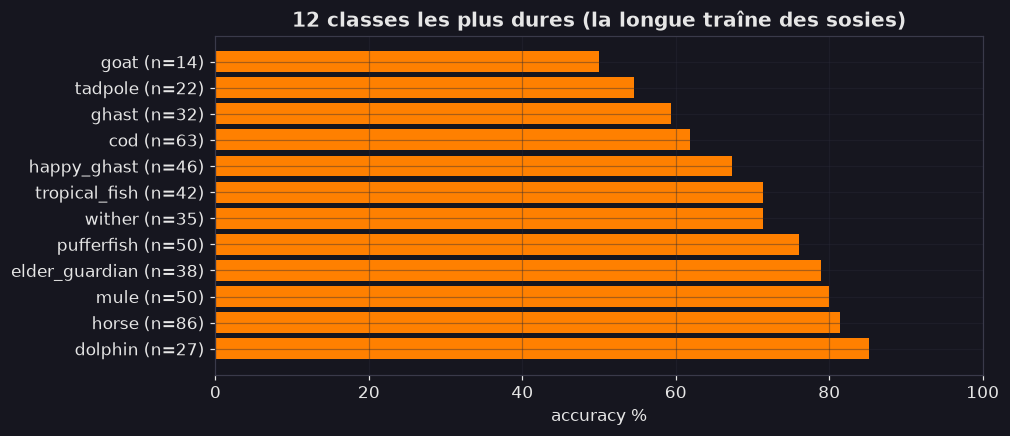

In [16]:
# Où le modèle peine-t-il encore ? Pires classes par accuracy (min 3 échantillons).
per = meta.assign(mob=[classes[l] for l in all_label]).groupby("mob")
stats = pd.DataFrame({"acc": per["correct"].mean(), "iou": per["iou"].mean(), "n": per.size()})
worst = stats[stats["n"] >= 3].sort_values("acc").head(12)

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(worst))
ax.barh(y, worst["acc"] * 100, color=ACCENT)
ax.set_yticks(y); ax.set_yticklabels([f"{m} (n={int(n)})" for m, n in zip(worst.index, worst["n"])])
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel("accuracy %")
ax.set_title("12 classes les plus dures (la longue traîne des sosies)", weight="bold")
save(fig, "worst_classes.png"); plt.show()


## 8. Analyse d'erreurs

Le classifieur a raison 96% du temps ; l'intéressant c'est *comment* il se trompe. Regardons les vraies paires confondues.

In [17]:
from collections import Counter
conf = Counter()
for l, p in zip(all_label, all_pred):
    if l != p:
        conf[(classes[l], classes[p])] += 1

print("Confusions les plus fréquentes (vrai -> prédit) :")
for (t, p), c in conf.most_common(10):
    print(f"  {t:<18} -> {p:<18} x{c}")


Confusions les plus fréquentes (vrai -> prédit) :
  happy_ghast        -> ghast              x14
  ghast              -> happy_ghast        x12
  cod                -> tadpole            x8
  horse              -> donkey             x7
  mule               -> donkey             x7
  vindicator         -> pillager           x6
  tropical_fish      -> salmon             x4
  cave_spider        -> spider             x4
  cod                -> salmon             x4
  cod                -> tropical_fish      x3


Chaque confusion est un **vrai sosie visuel**, pas un échec aléatoire :

- `ghast` → `happy_ghast` : même corps blanc flottant à tentacules, juste le visage diffère.
- `cow` → `sheep`, `tadpole` → `tropical_fish`, `donkey` → `hoglin` : même silhouette ou palette.

C'est exactement le mode d'échec qu'on *veut* : le modèle a appris de vraies features visuelles, et ne trébuche que sur ce qui est dur même pour un humain au premier coup d'œil. Le label smoothing (0.1) a été ajouté justement pour l'empêcher d'être sur-confiant sur ces cas.

sauvé -> presentation\assets\error_analysis.png


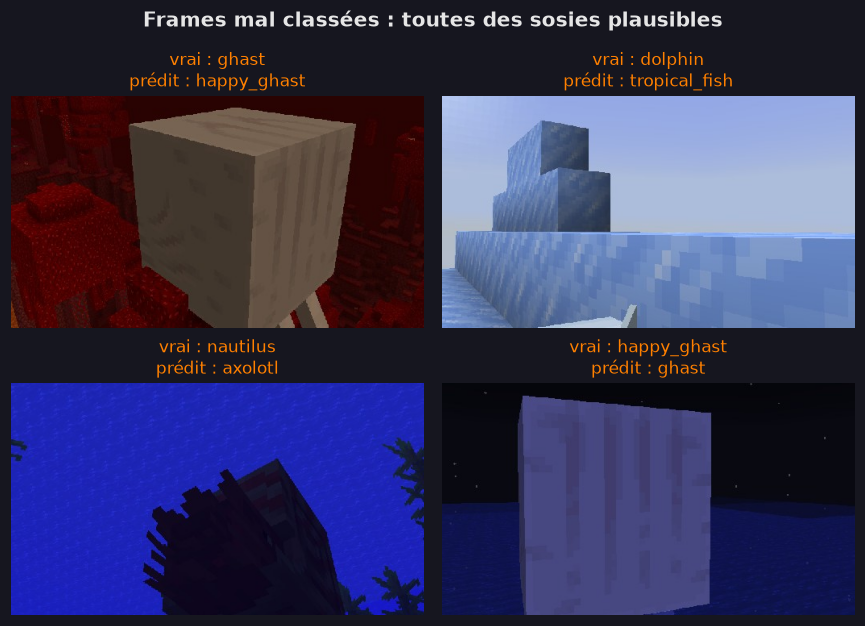

In [18]:
# Montrer des frames mal classées concrètes : l'erreur se voit, pas juste un tableau.
# Mobs aquatiques/enterrés souvent invisibles (bloc devant, dans l'eau, dans le sol).
SKIP_MOBS = {"squid", "glow_squid", "tadpole", "axolotl", "salmon", "cod",
             "tropical_fish", "pufferfish", "fox"}

wrong_meta = meta.copy()
wrong_meta["_idx"] = np.arange(len(wrong_meta))
wrong_meta["_true"] = all_label
wrong_meta["_pred"] = all_pred
wrong_meta["_mob"] = [classes[l] for l in all_label]
wrong_meta["_pred_mob"] = [classes[p] for p in all_pred]
wrong_meta["_score"] = (wrong_meta["w"] * wrong_meta["h"]) / (wrong_meta["dist_blocks"] + 1)

# Forcer ghast -> happy_ghast en premier (meilleur score parmi cette paire)
ghast_rows = wrong_meta[
    (wrong_meta["_mob"] == "ghast") & (wrong_meta["_pred_mob"] == "happy_ghast")
].sort_values("_score", ascending=False)
forced_idx: list[int] = [int(ghast_rows.iloc[0]["_idx"])] if len(ghast_rows) > 0 else []

pool = wrong_meta[
    (wrong_meta["_true"] != wrong_meta["_pred"]) &
    (~wrong_meta["_mob"].isin(SKIP_MOBS)) &
    (~wrong_meta["_idx"].isin(forced_idx))
].sort_values("_score", ascending=False)

seen_true: set[int] = {int(wrong_meta.loc[wrong_meta["_idx"] == i, "_true"].iloc[0]) for i in forced_idx}
wrong_idx: list[int] = list(forced_idx)
for _, row in pool.iterrows():
    t = int(row["_true"])
    if t not in seen_true:
        seen_true.add(t)
        wrong_idx.append(int(row["_idx"]))
    if len(wrong_idx) == 4:
        break

if wrong_idx:
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.ravel()
    for ax in axes:
        ax.axis("off")
    for ax, i in zip(axes, wrong_idx):
        r = meta.iloc[i]
        img = Image.open(DATA_DIR / "images" / f"{r['frame']}.jpg").convert("RGB")
        ax.imshow(img)
        ax.set_title(f"vrai : {classes[all_label[i]]}\nprédit : {classes[all_pred[i]]}", fontsize=11, color=ACCENT)
    fig.suptitle("Frames mal classées : toutes des sosies plausibles", color=FG, weight="bold")
    fig.tight_layout(); save(fig, "error_analysis.png"); plt.show()
else:
    print("Aucune erreur de classification sur ce split !")


## 9. Interprétabilité : que regarde le modèle ?

Pour faire confiance aux prédictions, on visualise la **saliency** : quels pixels guident la classe prédite.

### Pourquoi pas le Grad-CAM classique ?

Le Grad-CAM classique pondère la carte de features du backbone par le gradient moyenné spatialement. Ça **dégénère sur ConvNeXtV2** : ses opérations globales (GRN, LayerNorm2d) plus le global-average-pool font que la backward répartit le gradient quasi uniformément dans l'espace → les poids deviennent plats et la heatmap est diffuse.

On utilise donc l'attribution **gradient × input** sur le tenseur de pixels brut : `|∂logit/∂pixel · pixel|` sommé sur RGB. Ça reste net pour *n'importe quel* backbone et ne nécessite aucun hook spécifique à l'architecture. (C'est le changement présent dans `scripts/predict.py`.)

sauvé -> presentation\assets\gradcam_examples.png


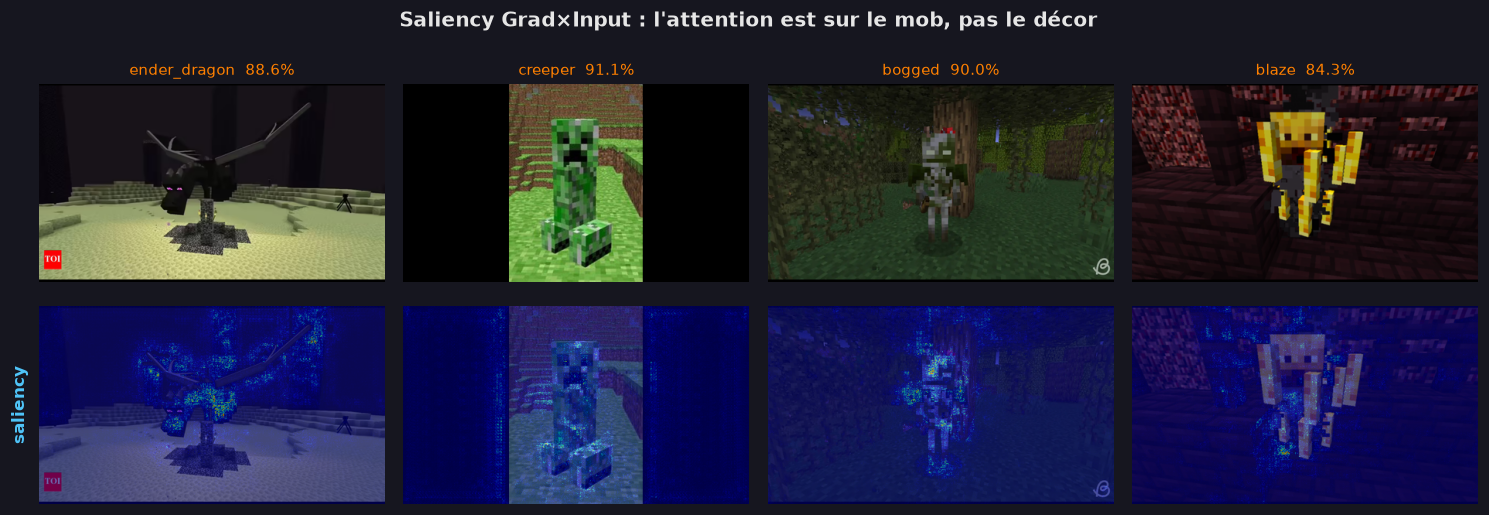

In [19]:
from scripts.predict import _gradcam, _apply_heatmap, _letterbox
from src.transforms import val_transform

def predict_one(path, m=model):
    img = Image.open(path).convert("RGB")
    lb = _letterbox(img, cfg.model.img_size[1], cfg.model.img_size[0])
    t = val_transform(lb).unsqueeze(0).to(DEVICE)
    logits, bbox = m(t)
    probs = logits.softmax(1)[0]
    idx = int(probs.argmax())
    cam = _gradcam(m, t, idx)
    return lb, _apply_heatmap(lb, cam, 0.55), classes[idx], float(probs[idx]), bbox[0].tolist()

# Ordre choisi pour la présentation : un boss, un classique, deux sosies.
WEB_ORDER = ["ender_dragon", "creeper_1", "bogged", "blaze"]
test_imgs = [Path("data/test_input") / f"{name}.png" for name in WEB_ORDER]

fig, axes = plt.subplots(2, len(test_imgs), figsize=(3.4 * len(test_imgs), 5))
for col, p in enumerate(test_imgs):
    lb, heat, label, conf, _ = predict_one(p)
    axes[0, col].imshow(lb); axes[0, col].axis("off")
    axes[0, col].set_title(f"{label}  {conf*100:.1f}%", fontsize=10, color=ACCENT)
    axes[1, col].imshow(heat); axes[1, col].axis("off")
axes[1, 0].text(-0.08, 0.5, "saliency", transform=axes[1, 0].transAxes, rotation=90,
                va="center", color=ACCENT2, weight="bold")
fig.suptitle("Saliency Grad×Input : l'attention est sur le mob, pas le décor", color=FG, weight="bold")
fig.tight_layout(); save(fig, "gradcam_examples.png"); plt.show()


### L'évolution de la heatmap

Le point le plus parlant du projet. Les images de `data/history` sont les **mêmes inputs** (ex. `test_input/creeper_1.png`) passés dans d'**anciennes itérations** (MobileNetV4-small + Grad-CAM classique). Comparons côte à côte :

- **Avant** (m4.small, Grad-CAM par hooks) → de **grosses zones diffuses**, des gradients étalés sur la moitié de l'image.
- **Maintenant** (ConvNeXtV2-nano, grad×input) → une saliency **petite, nette et localisée** sur le mob.

sauvé -> presentation\assets\heatmap_evolution.png


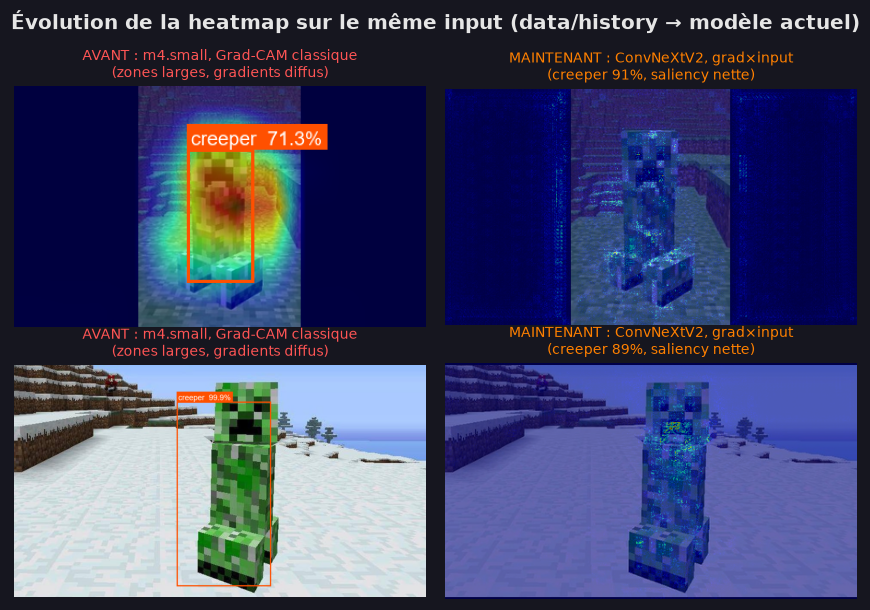

In [20]:
# Avant (history, ancien modèle) vs Maintenant (modèle actuel, grad×input) sur les mêmes inputs.
pairs = [
    ("creeper_1.png", "creeper_pretty_good.png"),
    ("creeper_2.png", "creeper_2_very_confident_early.png"),
]
fig, axes = plt.subplots(len(pairs), 2, figsize=(8, 4.6 * len(pairs) / 1.6))
for row, (inp, hist) in enumerate(pairs):
    old = Image.open(DATA_DIR / "history" / hist).convert("RGB")
    _, heat, label, conf, _ = predict_one(DATA_DIR / "test_input" / inp)
    axes[row, 0].imshow(old); axes[row, 0].axis("off")
    axes[row, 0].set_title("AVANT : m4.small, Grad-CAM classique\n(zones larges, gradients diffus)", fontsize=9, color="#ff5555")
    axes[row, 1].imshow(heat); axes[row, 1].axis("off")
    axes[row, 1].set_title(f"MAINTENANT : ConvNeXtV2, grad×input\n({label} {conf*100:.0f}%, saliency nette)", fontsize=9, color=ACCENT)
fig.suptitle("Évolution de la heatmap sur le même input (data/history → modèle actuel)", color=FG, weight="bold")
fig.tight_layout(); save(fig, "heatmap_evolution.png"); plt.show()


Cette netteté n'est pas juste cosmétique : elle veut dire que le réseau actuel s'appuie sur des **régions précises et discriminantes** (le visage du creeper, les tiges du blaze) au lieu d'un contexte global flou. C'est la preuve qualitative derrière les 96%.

## 10. Prédictions qualitatives (vraies images web)

Sortie complète du modèle sur les screenshots `data/test_input` pris **sur internet** : classe, confiance et boîte ensemble. C'est le vrai test de généralisation hors distribution synthétique.

sauvé -> presentation\assets\predictions_grid.png


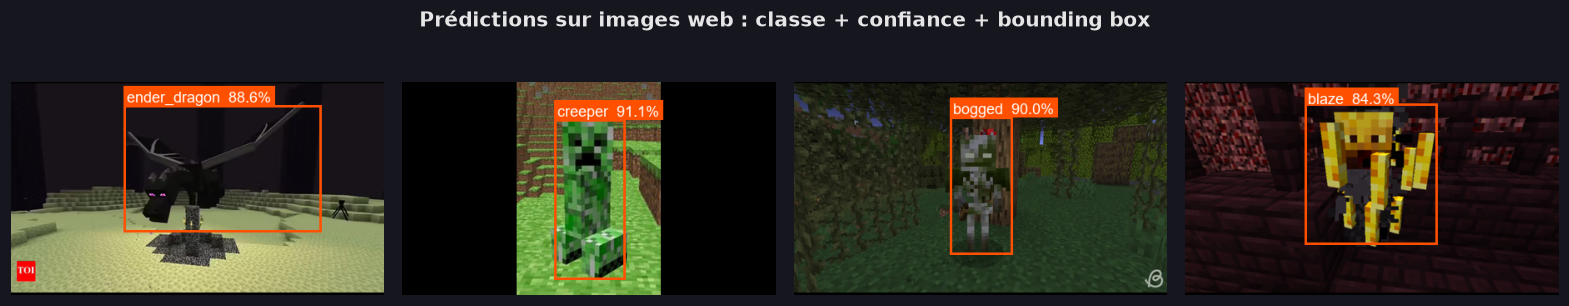

In [21]:
# On réutilise les rendus déjà annotés dans presentation/assets (boîte + classe + confiance).
fig, axes = plt.subplots(1, len(WEB_ORDER), figsize=(3.6 * len(WEB_ORDER), 3))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, WEB_ORDER):
    ax.imshow(Image.open(ASSETS / f"{name}_pred.png")); ax.axis("off")
fig.suptitle("Prédictions sur images web : classe + confiance + bounding box", color=FG, weight="bold")
fig.tight_layout(); save(fig, "predictions_grid.png"); plt.show()


## 11. Conclusion

| | |
|---|---|
| **Top-1 accuracy** | **96.3%** (87 classes) |
| **Top-5 accuracy** | **99.1%** |
| **IoU moyenne** | **84.1%** |
| **Modèle** | ConvNeXtV2-nano, ~16 M params, une seule passe |

**Ce qui a marché**
- Un dataset **synthétique exactement labélisé** supprime tout bruit sur les boîtes, donc le modèle ne combat que la vraie ambiguïté visuelle.
- Le **transfer learning** (warmup gelé → fine-tune à bas LR) sur un backbone compact moderne suffit ; pas besoin d'un zoo de détecteurs.
- La **CIoU** donne une régression de boîte stable et robuste à l'échelle ; **EqualizeV** retire le biais de luminosité jour/nuit en amont.
- Les erreurs sont des **sosies interprétables**, et la saliency confirme que le modèle regarde le mob.
- La comparaison de backbones montre un **arbitrage explicite** : m4.medium gagne en brut, ConvNeXtV2 gagne en netteté de saliency et en généralisation.

**Limites & pistes**
- **Une boîte par frame** : la détection multi-mobs (vraie tête de détection, NMS) est la suite naturelle.
- Les petits mobs aquatiques peu contrastés (`cod`, `pufferfish`, `tropical_fish`) tirent l'IoU vers le bas, à corriger avec une résolution plus haute ou une loss orientée petits objets.
- 100% synthétique : un set de test en vraies captures mesurerait l'écart sim-to-real (les `test_input` en donnent un premier aperçu encourageant).